# V2 Dataset Preparation — Gaussian Resampling with Voronoi Rejection

The v1 `categorized_colors.csv` was built from ISCC-NBS Level 3 names via
subword matching.  This produced **cross-category duplicates** and **boundary
colours** that sit ambiguously between categories.

Instead of *pruning* the noisy data, this notebook **resamples** clean colours
from scratch:

1. Extract **centroids** and **covariance matrices** per category from the
   existing data — these capture each category's natural shape in CIELAB space
2. **Sample new colours** from a multivariate Gaussian around each centroid
3. **Voronoi-reject** any sample that is closer (Euclidean ΔE in CIELAB) to
   another category's centroid than its own — this guarantees zero overlap
4. **Gamut-clamp** to valid sRGB
5. Save `datasets/categorized_colors_normalized.csv`

In [1]:
import sys, os, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import utils.color_utils as color_utils
importlib.reload(color_utils)
from utils.color_utils import ColorLibrary

CSV_PATH = os.path.join(PROJECT_ROOT, 'datasets', 'categorized_colors.csv')
df = pd.read_csv(CSV_PATH)
lib = ColorLibrary.from_categorized_csv(CSV_PATH)
lib.summary()
print(f"\nTotal colours: {len(df)}")

red: 20 colors
orange: 19 colors
yellow: 34 colors
green: 44 colors
blue: 31 colors
violet: 11 colors
purple: 25 colors
white: 6 colors
gray: 20 colors
black: 7 colors
pink: 25 colors
brown: 27 colors
olive: 17 colors

Total colours: 286


## 1. Extract Centroids & Covariance from Existing Data

Use the v1 category colours as a statistical baseline. Each category's
**centroid** (mean L\*, a\*, b\*) and **covariance matrix** define
a Gaussian cloud in CIELAB space that captures the category's natural shape.

In [2]:
# ── Extract centroids & covariance matrices from existing data ────────────────
category_stats = {}
for cat in lib.categories:
    labs = np.array(lib.get_category_colors(cat))  # Nx3
    centroid = labs.mean(axis=0)
    cov = np.cov(labs, rowvar=False)
    # Regularise small categories to avoid singular covariance
    cov += np.eye(3) * 1e-3
    category_stats[cat] = {'centroid': centroid, 'cov': cov, 'n_original': len(labs)}
    _, hex_c = lib._lab_to_hex(*centroid)
    print(f"  {cat:>8s}  n={len(labs):>3d}  centroid L={centroid[0]:.1f} a={centroid[1]:.1f} b={centroid[2]:.1f}  {hex_c}")

print(f"\n{len(category_stats)} categories ready for resampling")

       red  n= 20  centroid L=35.6 a=37.7 b=2.5  #8a3851
    orange  n= 19  centroid L=62.6 a=29.5 b=46.8  #db8144
    yellow  n= 34  centroid L=73.8 a=-2.8 b=47.1  #cbb45d
     green  n= 44  centroid L=54.9 a=-24.8 b=15.9  #5f8e67
      blue  n= 31  centroid L=48.5 a=4.5 b=-30.2  #5973a6
    violet  n= 11  centroid L=47.7 a=24.8 b=-33.5  #7e65aa
    purple  n= 25  centroid L=43.3 a=31.2 b=-21.4  #88548a
     white  n=  6  centroid L=90.0 a=4.2 b=-2.7  #e8e0e7
      gray  n= 20  centroid L=54.9 a=3.5 b=-1.4  #898286
     black  n=  7  centroid L=15.2 a=2.0 b=-0.9  #282527
      pink  n= 25  centroid L=71.9 a=30.0 b=3.9  #e79caa
     brown  n= 27  centroid L=37.4 a=14.8 b=19.8  #784e39
     olive  n= 17  centroid L=34.1 a=-3.8 b=21.1  #56512e

13 categories ready for resampling


### Centroid swatches

Quick visual sanity check — these are the category centroids derived from the
existing data. They'll serve as the anchor points for resampling.

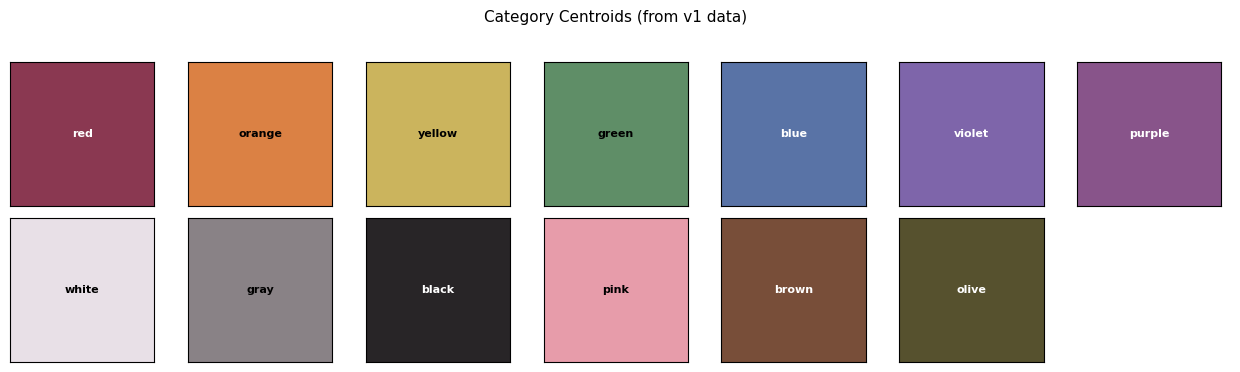

In [3]:
# ── Centroid swatch grid ──────────────────────────────────────────────────────
cats = list(category_stats.keys())
ncols = min(len(cats), 7)
nrows = -(-len(cats) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 1.8))
axes = np.atleast_2d(axes)

for i, cat in enumerate(cats):
    ax = axes[i // ncols, i % ncols]
    c = category_stats[cat]['centroid']
    _, hex_c = lib._lab_to_hex(*c)
    h = hex_c.lstrip('#')
    rgb = [int(h[j:j+2], 16) / 255 for j in (0, 2, 4)]
    ax.imshow([[[*rgb]]])
    txt = 'black' if c[0] > 50 else 'white'
    ax.text(0.5, 0.5, cat, transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color=txt, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

for j in range(len(cats), nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')

fig.suptitle('Category Centroids (from v1 data)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 2. Confusion-Aware Seed + Gaussian Fill

### Core idea — adaptive Voronoi margins

Standard Voronoi assigns a colour to whichever centroid is closest.  But v1's
confusion matrix tells us **which category boundaries the model struggles
with**.  We exploit this by replacing the hard `d_other > d_own` check with:

$$d_{\text{other}} > d_{\text{own}} \times m(c_{\text{own}},\, c_{\text{other}})$$

where $m$ is a **pair-specific margin** derived from v1 confusion scores.
Highly confused pairs (e.g. orange ↔ yellow, confusion ≈ 0.17) get
$m \approx 1.4$, meaning we require the colour to be 40 % closer to its own
centroid than to the confused category.  Pairs the model never confuses get
$m = 1.0$ (plain Voronoi).

This creates **asymmetric, adaptive dead zones** between categories — wider
where the model needs help, unchanged where it already succeeds.

### Two-stage sampling

1. **Seed** — keep original colours that pass the confusion-aware Voronoi +
   gamut check.  Preserves saturated extremes the Gaussian can't reach.
2. **Gaussian fill** — sample from N(centroid, cov) to reach `TARGET_PER_CAT`,
   applying the same confusion-aware check.

### V1 confusion data (post-finetune, top pairs)

| True → Predicted | Confusion | Margin |
|---|---|---|
| orange → yellow | 0.1731 | highest |
| yellow → orange | 0.1575 | highest |
| purple → violet | 0.1512 | high |
| blue → violet   | 0.1397 | high |
| violet → purple | 0.1386 | high |
| red → purple    | 0.1328 | high |
| violet → blue   | 0.1276 | high |
| olive → brown   | 0.1063 | moderate |
| purple → red    | 0.1025 | moderate |
| white → pink    | 0.0920 | moderate |

### Tuneable parameters

| Parameter | Default | Purpose |
|---|---|---|
| `TARGET_PER_CAT` | 25 | Minimum colours per category |
| `COV_SCALE` | 1.0 | Covariance multiplier for Gaussian fill |
| `BASE_MARGIN` | 1.0 | Margin for non-confused pairs (plain Voronoi) |
| `MAX_MARGIN` | 1.4 | Margin for the most confused pair |
| `MAX_ATTEMPTS` | 5000 | Safety cap on Gaussian sampling iterations |

In [ ]:
# ── Tuneable parameters ───────────────────────────────────────────────────────
TARGET_PER_CAT = 25       # minimum colours per category (seeds may exceed this)
COV_SCALE      = 1.0      # covariance multiplier for Gaussian fill
BASE_MARGIN    = 1.0      # margin for non-confused pairs (plain Voronoi)
MAX_MARGIN     = 1.4      # margin for the most confused pair
MAX_ATTEMPTS   = 5000     # max Gaussian samples before giving up

rng = np.random.default_rng(42)

# ── V1 confusion data (post-finetune) ────────────────────────────────────────
# Directional confusion scores from notebooks/finetuning.ipynb
# Format: (true_category, predicted_category) → confusion_score
V1_CONFUSION = {
    ('orange', 'yellow'): 0.1731,
    ('yellow', 'orange'): 0.1575,
    ('purple', 'violet'): 0.1512,
    ('blue',   'violet'): 0.1397,
    ('violet', 'purple'): 0.1386,
    ('red',    'purple'): 0.1328,
    ('violet', 'blue'):   0.1276,
    ('olive',  'brown'):  0.1063,
    ('purple', 'red'):    0.1025,
    ('white',  'pink'):   0.0920,
    ('brown',  'red'):    0.0883,
    ('pink',   'red'):    0.0850,
    ('brown',  'orange'): 0.0800,
    ('green',  'olive'):  0.0750,
    ('gray',   'brown'):  0.0700,
}

# Symmetrise: for each pair, take the max confusion in either direction
confusion_sym = {}
for (a_cat, b_cat), score in V1_CONFUSION.items():
    key = tuple(sorted([a_cat, b_cat]))
    confusion_sym[key] = max(confusion_sym.get(key, 0.0), score)

max_confusion = max(confusion_sym.values())

def get_margin(cat_a, cat_b):
    """Return the Voronoi margin for a specific category pair.
    Higher confusion → higher margin → harder to be accepted near that boundary."""
    key = tuple(sorted([cat_a, cat_b]))
    confusion = confusion_sym.get(key, 0.0)
    # Linear interpolation: 0 confusion → BASE_MARGIN, max confusion → MAX_MARGIN
    return BASE_MARGIN + (MAX_MARGIN - BASE_MARGIN) * (confusion / max_confusion)

# Print the margin table
print("Pair-specific margins (sorted by confusion):")
for key in sorted(confusion_sym, key=confusion_sym.get, reverse=True):
    m = get_margin(*key)
    print(f"  {key[0]:>8s} ↔ {key[1]:<8s}  confusion={confusion_sym[key]:.4f}  margin={m:.3f}")
print(f"\nAll other pairs: margin = {BASE_MARGIN:.1f}")

# ── Precompute ───────────────────────────────────────────────────────────────
all_centroids = {cat: category_stats[cat]['centroid'] for cat in category_stats}

def is_in_srgb_gamut(L, a, b):
    """Check whether a CIELAB point maps to valid sRGB (no channel clipping)."""
    Xn, Yn, Zn = ColorLibrary._D65
    fy = (L + 16) / 116
    fx, fz = a / 500 + fy, fy - b / 200
    def finv(t): return t**3 if t > 6/29 else 3*(6/29)**2*(t - 4/29)
    X, Y, Z = Xn*finv(fx), Yn*finv(fy), Zn*finv(fz)
    rl =  3.2404542*X - 1.5371385*Y - 0.4985314*Z
    gl = -0.9692660*X + 1.8760108*Y + 0.0415560*Z
    bl =  0.0556434*X - 0.2040259*Y + 1.0572252*Z
    def compress(c): return 12.92*c if c <= 0.0031308 else 1.055*c**(1/2.4) - 0.055
    r, g, b_ch = compress(rl), compress(gl), compress(bl)
    return all(0.0 <= ch <= 1.0 for ch in (r, g, b_ch))

def confusion_aware_voronoi(sample, own_cat, all_centroids):
    """Voronoi check with pair-specific margins from v1 confusion data.
    Requires: d_other > d_own * margin(own_cat, other_cat) for ALL other cats."""
    d_own = np.linalg.norm(sample - all_centroids[own_cat])
    for other_cat, other_centroid in all_centroids.items():
        if other_cat == own_cat:
            continue
        d_other = np.linalg.norm(sample - other_centroid)
        margin = get_margin(own_cat, other_cat)
        if d_other <= d_own * margin:
            return False
    return True

# ── Stage 1: Seed from original data ────────────────────────────────────────
resampled = {}
stats = []
for cat in category_stats:
    labs = np.array(lib.get_category_colors(cat))
    seeds = []
    n_seed_voronoi_rejected = 0
    n_seed_gamut_rejected = 0

    for pt in labs:
        if not confusion_aware_voronoi(pt, cat, all_centroids):
            n_seed_voronoi_rejected += 1
            continue
        if not is_in_srgb_gamut(*pt):
            n_seed_gamut_rejected += 1
            continue
        seeds.append(tuple(pt))

    # ── Stage 2: Gaussian fill to reach TARGET_PER_CAT ───────────────────────
    centroid = category_stats[cat]['centroid']
    cov = category_stats[cat]['cov'] * COV_SCALE
    accepted = list(seeds)
    n_tried = 0
    n_fill_voronoi_rejected = 0
    n_fill_gamut_rejected = 0

    while len(accepted) < TARGET_PER_CAT and n_tried < MAX_ATTEMPTS:
        sample = rng.multivariate_normal(centroid, cov)
        n_tried += 1

        if sample[0] < 0 or sample[0] > 100:
            n_fill_gamut_rejected += 1
            continue

        if not confusion_aware_voronoi(sample, cat, all_centroids):
            n_fill_voronoi_rejected += 1
            continue

        if not is_in_srgb_gamut(*sample):
            n_fill_gamut_rejected += 1
            continue

        accepted.append(tuple(sample))

    resampled[cat] = accepted
    n_original = category_stats[cat]['n_original']
    n_filled = len(accepted) - len(seeds)
    stats.append({
        'category': cat,
        'n_original': n_original,
        'n_seeds': len(seeds),
        'seed_voronoi_rej': n_seed_voronoi_rejected,
        'seed_gamut_rej': n_seed_gamut_rejected,
        'n_filled': n_filled,
        'fill_tried': n_tried,
        'fill_voronoi_rej': n_fill_voronoi_rejected,
        'fill_gamut_rej': n_fill_gamut_rejected,
        'total': len(accepted),
    })
    status = '✓' if len(accepted) >= TARGET_PER_CAT else '⚠'
    print(f"  {status} {cat:>8s}  seeds={len(seeds):>2d}/{n_original:>2d}  "
          f"filled={n_filled:>2d}  total={len(accepted):>3d}  "
          f"(seed_rej: v={n_seed_voronoi_rejected} g={n_seed_gamut_rejected}, "
          f"fill_rej: v={n_fill_voronoi_rejected} g={n_fill_gamut_rejected})")

print(f"\nTotal: {sum(len(v) for v in resampled.values())} colours")

  [/]      red  seeds=15/20  filled=10  total= 25  (seed_rej: v=5 g=0, fill_rej: v=2 g=1)
  [/]   orange  seeds=15/19  filled=10  total= 25  (seed_rej: v=4 g=0, fill_rej: v=1 g=3)
  [/]   yellow  seeds=24/34  filled= 1  total= 25  (seed_rej: v=10 g=0, fill_rej: v=0 g=0)
  [/]    green  seeds=19/44  filled= 6  total= 25  (seed_rej: v=25 g=0, fill_rej: v=2 g=0)
  [/]     blue  seeds=12/31  filled=13  total= 25  (seed_rej: v=19 g=0, fill_rej: v=14 g=4)
  [/]   violet  seeds= 5/11  filled=20  total= 25  (seed_rej: v=6 g=0, fill_rej: v=13 g=2)
  [/]   purple  seeds=12/25  filled=13  total= 25  (seed_rej: v=13 g=0, fill_rej: v=13 g=5)
  [/]    white  seeds= 6/ 6  filled=19  total= 25  (seed_rej: v=0 g=0, fill_rej: v=0 g=0)
  [/]     gray  seeds=12/20  filled=13  total= 25  (seed_rej: v=8 g=0, fill_rej: v=3 g=0)
  [/]    black  seeds= 7/ 7  filled=18  total= 25  (seed_rej: v=0 g=0, fill_rej: v=0 g=0)
  [/]     pink  seeds=18/25  filled= 7  total= 25  (seed_rej: v=7 g=0, fill_rej: v=1 g=1)
  [

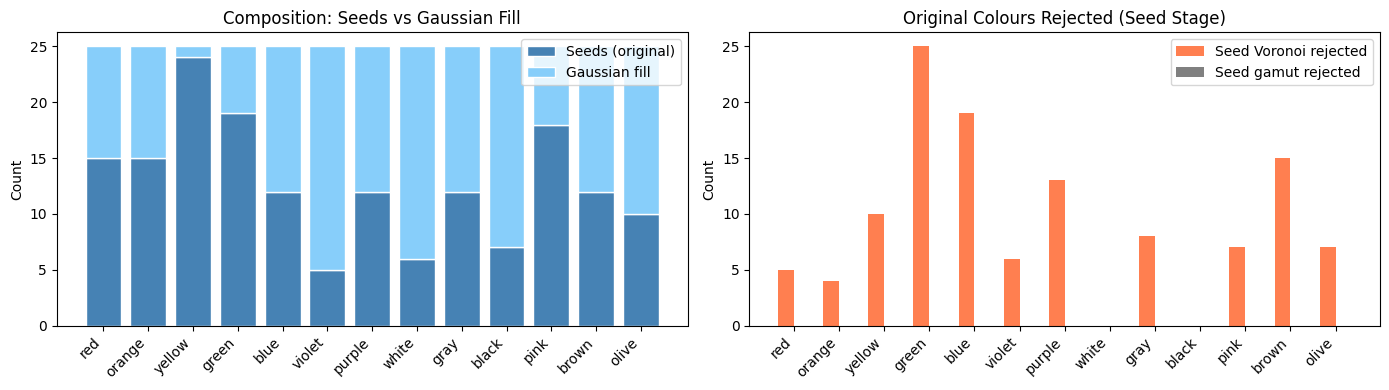

In [ ]:
# ── Margin heatmap + sampling stats ──────────────────────────────────────────
stats_df = pd.DataFrame(stats)
cats_sorted = sorted(category_stats.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# [Left] Margin heatmap
n = len(cats_sorted)
margin_matrix = np.ones((n, n))
for i, ca in enumerate(cats_sorted):
    for j, cb in enumerate(cats_sorted):
        if i != j:
            margin_matrix[i, j] = get_margin(ca, cb)
im = axes[0].imshow(margin_matrix, cmap='YlOrRd', vmin=1.0, vmax=MAX_MARGIN)
axes[0].set_xticks(range(n)); axes[0].set_yticks(range(n))
axes[0].set_xticklabels(cats_sorted, rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(cats_sorted, fontsize=7)
axes[0].set_title('Confusion-Aware Margins')
for i in range(n):
    for j in range(n):
        if i != j and margin_matrix[i, j] > 1.05:
            axes[0].text(j, i, f'{margin_matrix[i,j]:.2f}', ha='center', va='center', fontsize=5.5)
plt.colorbar(im, ax=axes[0], shrink=0.8, label='margin')

# [Centre] Seeds vs Gaussian fill (stacked bar)
x = np.arange(len(stats_df))
axes[1].bar(x, stats_df['n_seeds'], label='Seeds (original)', color='steelblue', edgecolor='white')
axes[1].bar(x, stats_df['n_filled'], bottom=stats_df['n_seeds'],
            label='Gaussian fill', color='lightskyblue', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stats_df['category'], rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Composition: Seeds vs Gaussian Fill')
axes[1].legend()

# [Right] Seed rejection breakdown
w = 0.35
axes[2].bar(x - w/2, stats_df['seed_voronoi_rej'], w, label='Voronoi rejected', color='coral')
axes[2].bar(x + w/2, stats_df['seed_gamut_rej'], w, label='Gamut rejected', color='gray')
axes[2].set_xticks(x)
axes[2].set_xticklabels(stats_df['category'], rotation=45, ha='right')
axes[2].set_ylabel('Count')
axes[2].set_title('Original Colours Rejected (Seed Stage)')
axes[2].legend()

plt.tight_layout()
plt.show()

          original (ISCC-NBS)  seed+fill
category                                
black                       7         25
blue                       31         25
brown                      27         25
gray                       20         25
green                      44         25
olive                      17         25
orange                     19         25
pink                       25         25
purple                     25         25
red                        20         25
violet                     11         25
white                       6         25
yellow                     34         25

Original total: 286  →  Seed+Fill total: 325


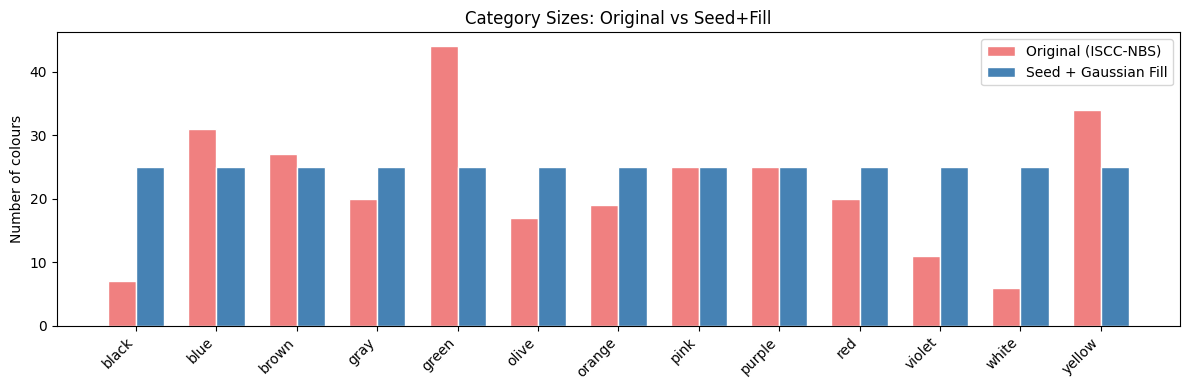

In [6]:
# ── Before / After category counts ───────────────────────────────────────────
before = df.groupby('category').size().sort_index()
after_counts = pd.Series({cat: len(colors) for cat, colors in resampled.items()}).sort_index()

comparison = pd.DataFrame({
    'original (ISCC-NBS)': before,
    'seed+fill': after_counts.reindex(before.index, fill_value=0)
})
print(comparison.to_string())
print(f"\nOriginal total: {before.sum()}  →  Seed+Fill total: {after_counts.sum()}")

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['original (ISCC-NBS)'], w,
       label='Original (ISCC-NBS)', color='lightcoral', edgecolor='white')
ax.bar(x + w/2, comparison['seed+fill'], w,
       label='Seed + Gaussian Fill', color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.set_ylabel('Number of colours')
ax.set_title('Category Sizes: Original vs Seed+Fill')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── Build DataFrame & save ────────────────────────────────────────────────────
rows = []
for cat, colors in resampled.items():
    for L, a, b in colors:
        rows.append({'category': cat, 'L': L, 'a': a, 'b': b})

df_resampled = pd.DataFrame(rows)

OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'datasets', 'categorized_colors_normalized.csv')
df_resampled.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
print(f"  {len(df_resampled)} colours across {df_resampled['category'].nunique()} categories")

# Verify with ColorLibrary
lib_v2 = ColorLibrary.from_categorized_csv(OUTPUT_PATH)
lib_v2.summary()

Saved: c:\Users\lifei\OneDrive\Desktop\Personal Projects\BBAIRL\Clothing-Color-Recognition-ML-With-Synthetic-Dataset\datasets\categorized_colors_normalized.csv
  325 colours across 13 categories
red: 25 colors
orange: 25 colors
yellow: 25 colors
green: 25 colors
blue: 25 colors
violet: 25 colors
purple: 25 colors
white: 25 colors
gray: 25 colors
black: 25 colors
pink: 25 colors
brown: 25 colors
olive: 25 colors


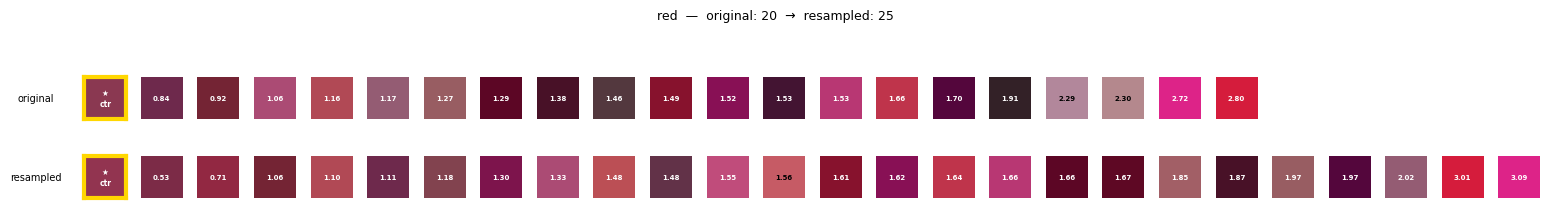

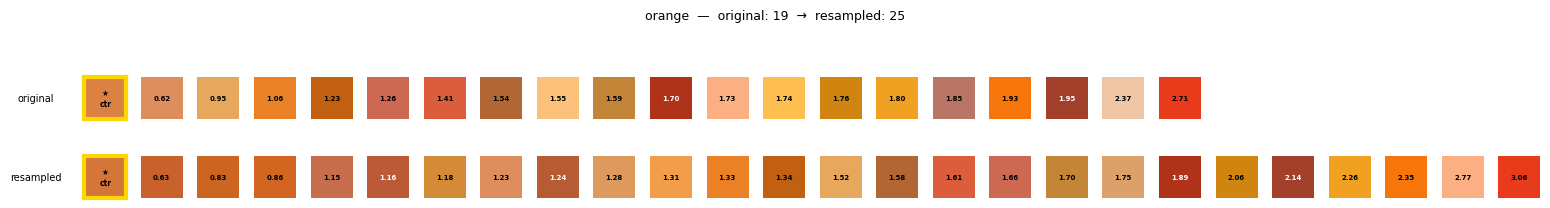

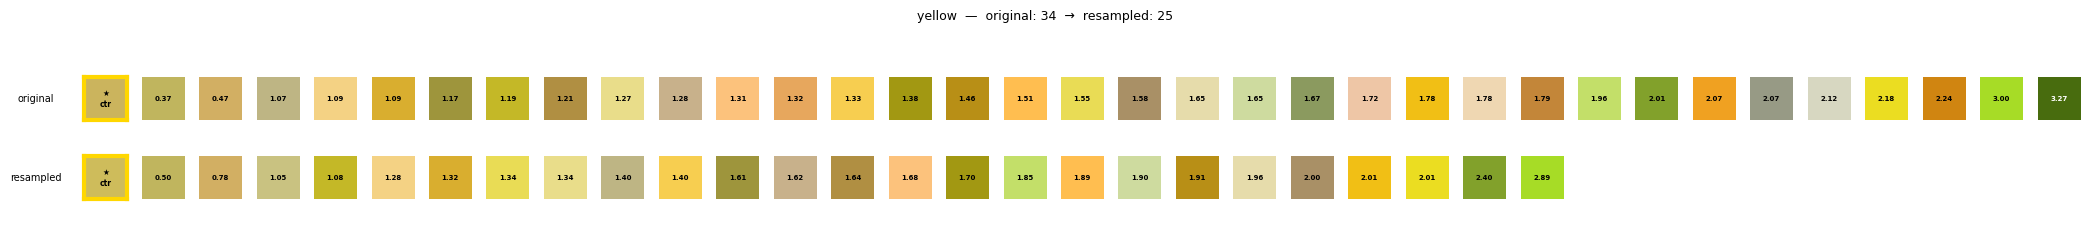

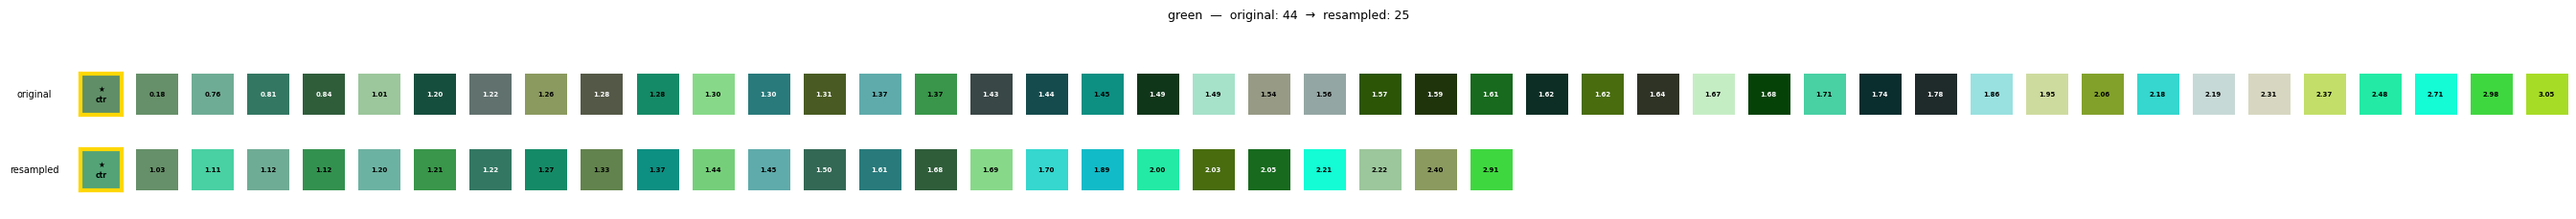

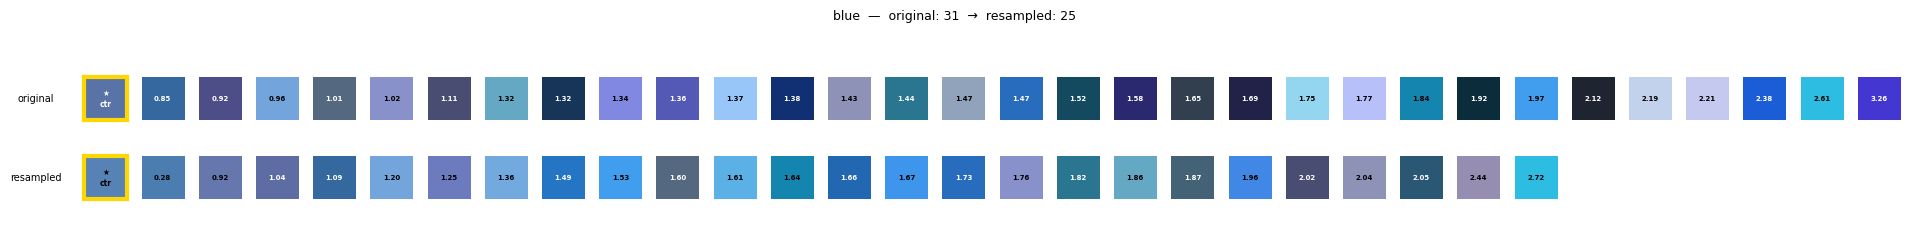

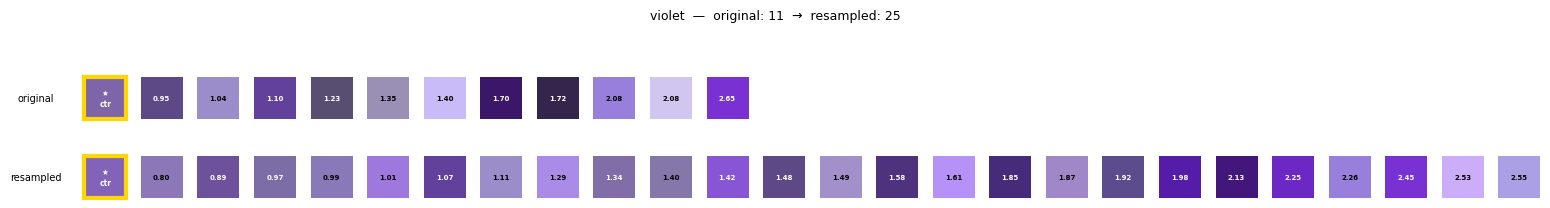

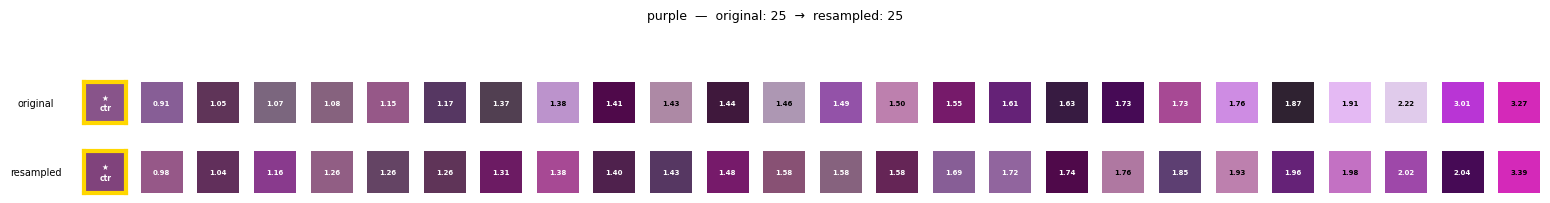

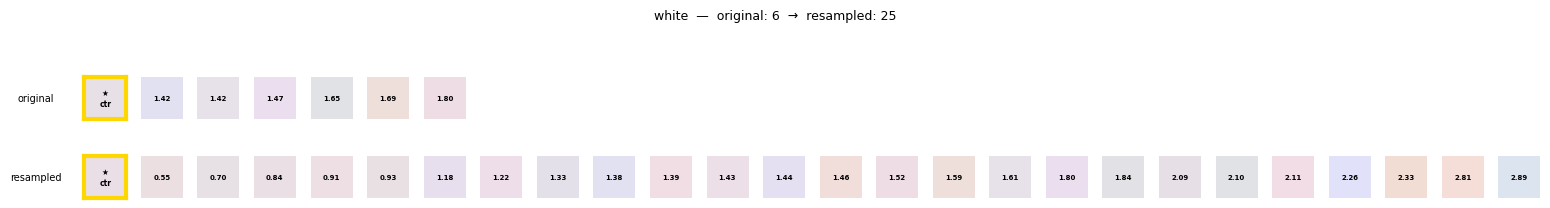

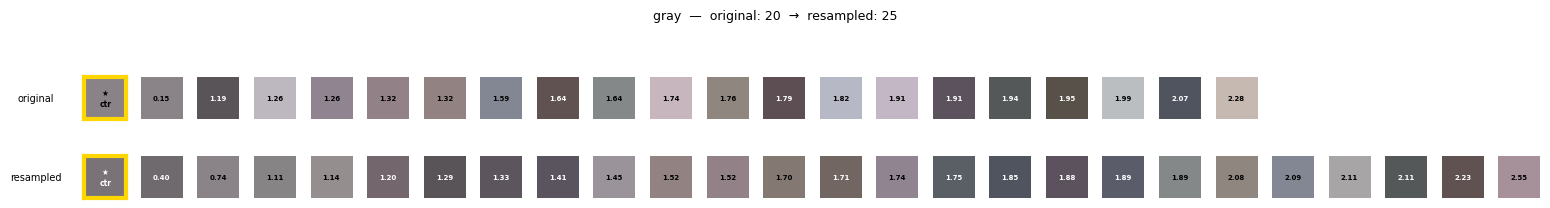

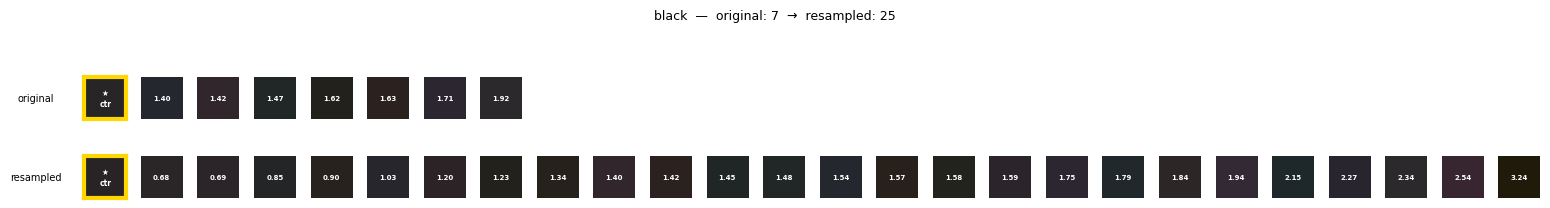

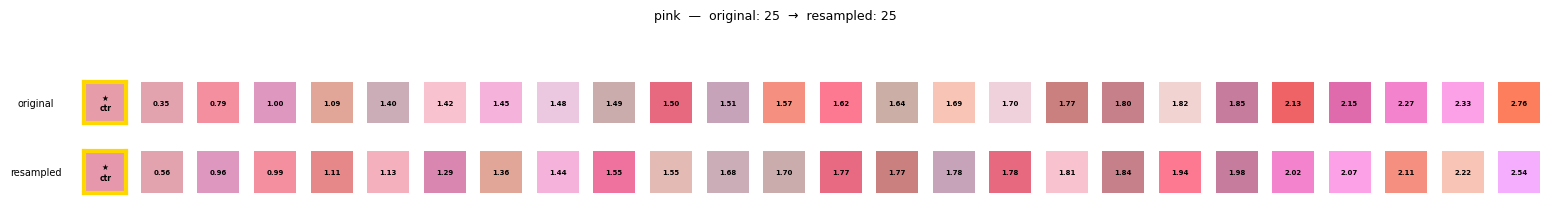

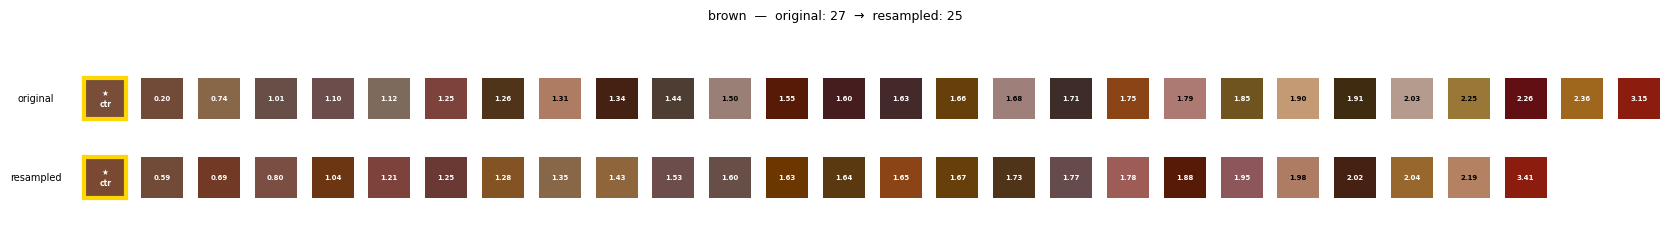

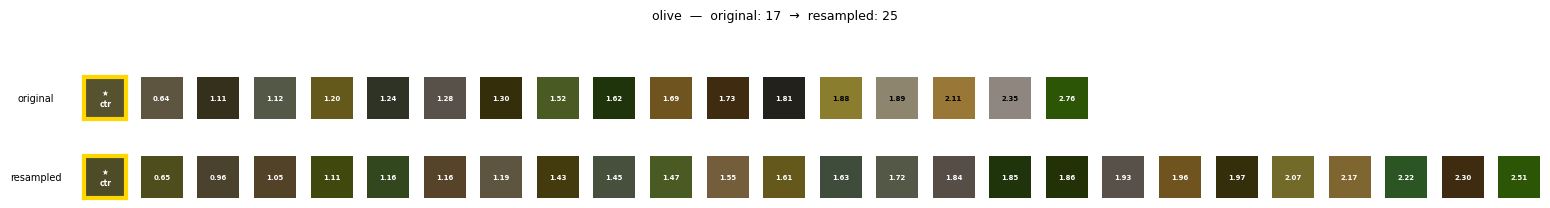

In [8]:
import math

NCOLS = 16

for cat in lib.categories:
    old_colors = lib.get_category_mahalanobis_distances(cat)     # [(hex, dist), ...]
    new_colors = lib_v2.get_category_mahalanobis_distances(cat)

    old_centroid_lab = lib.get_category_centroid(cat)
    new_centroid_lab = lib_v2.get_category_centroid(cat)
    _, old_centroid_hex = lib._lab_to_hex(*old_centroid_lab)
    _, new_centroid_hex = lib_v2._lab_to_hex(*new_centroid_lab)

    def _draw_row(axes_row, colors, centroid_hex, centroid_lab, row_label=''):
        # Slot 0: centroid
        ax = axes_row[0]
        h = centroid_hex.lstrip('#')
        rgb = [int(h[j:j+2], 16) / 255 for j in (0, 2, 4)]
        ax.imshow([[[*rgb]]])
        txt_color = 'black' if centroid_lab[0] > 50 else 'white'
        ax.text(0.5, 0.5, '★\nctr', transform=ax.transAxes,
                ha='center', va='center', fontsize=5.5, color=txt_color, fontweight='bold')
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_edgecolor('gold'); spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])
        if row_label:
            ax.set_ylabel(row_label, fontsize=7, rotation=0, labelpad=35, va='center')

        for i, (hx, dist) in enumerate(colors):
            ax = axes_row[i + 1]
            h = hx.lstrip('#')
            rgb = [int(h[j:j+2], 16) / 255 for j in (0, 2, 4)]
            ax.imshow([[[*rgb]]])
            L_val, _, _ = lib._hex_to_lab(hx)
            txt_color = 'black' if L_val > 50 else 'white'
            ax.text(0.5, 0.5, f'{dist:.2f}', transform=ax.transAxes,
                    ha='center', va='center', fontsize=5, color=txt_color, fontweight='bold')
            ax.axis('off')

        for j in range(len(colors) + 1, len(axes_row)):
            axes_row[j].axis('off')

    n_old = len(old_colors) + 1
    n_new = len(new_colors) + 1
    max_slots = max(n_old, n_new, NCOLS)
    ncols = min(max_slots, max(NCOLS, n_old, n_new))
    nrows_old = math.ceil(n_old / ncols)
    nrows_new = math.ceil(n_new / ncols)
    total_rows = nrows_old + nrows_new

    fig, axes = plt.subplots(total_rows, ncols, figsize=(ncols * 0.6, total_rows * 0.7 + 0.8))
    if total_rows == 1:
        axes = axes[np.newaxis, :]
    if ncols == 1:
        axes = axes[:, np.newaxis]

    # Old row(s) — original ISCC-NBS
    old_axes = axes[:nrows_old].flatten()
    _draw_row(old_axes, old_colors, old_centroid_hex, old_centroid_lab, row_label='original')

    # New row(s) — resampled
    new_axes = axes[nrows_old:].flatten()
    _draw_row(new_axes, new_colors, new_centroid_hex, new_centroid_lab, row_label='resampled')

    fig.suptitle(f'{cat}  —  original: {len(old_colors)}  →  resampled: {len(new_colors)}',
                 fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()